# Proyek: Deteksi Anomali Spektrum RF Cerdas
## 03 - Pelatihan Model & Analisa Pola

**Tujuan Notebook:** Menggunakan data fitur yang telah di-engineer untuk melatih model *unsupervised learning*. Tujuannya adalah agar model dapat secara otomatis mengelompokkan (cluster) data pengukuran ke dalam 'profil-profil sinyal' yang berbeda. Model yang terlatih kemudian akan disimpan untuk digunakan dalam sistem deteksi live.

### Pendekatan: Clustering dengan PCA

Kita akan menggunakan kombinasi teknik yang kuat untuk analisis data tak berlabel:

1.  **StandardScaler:** Menyamakan skala semua fitur numerik agar tidak ada satu fitur yang mendominasi hanya karena unitnya berbeda (misalnya, frekuensi dalam MHz vs. power dalam dB).
2.  **Principal Component Analysis (PCA):** Teknik reduksi dimensi yang akan memproyeksikan data fitur kita ke dalam ruang 2D. Ini memungkinkan kita untuk memvisualisasikan data dan membantu algoritma clustering bekerja lebih efektif.
3.  **K-Means Clustering:** Algoritma yang akan menemukan pusat-pusat kelompok (centroid) dalam data PCA dan mengelompokkan setiap titik data ke cluster terdekat.

Hasilnya adalah 'peta' dari profil-profil sinyal yang ada di data training kita.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import joblib

plt.style.use('seaborn-v0_8-whitegrid')

### Memuat Data Fitur

In [2]:
PROCESSED_DATA_PATH = '../data/processed/'
feature_matrix = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'training_features.csv'), index_col='file')

feature_matrix.head()

,noise_floor_db,num_signals,strongest_signal_power_db,strongest_signal_freq_mhz,strongest_signal_bw_mhz
file,,,,,
1000_anomali_1,-47.6,3,-13.9,995.0,13.6
1000_anomali_2,-47.6,3,-13.8,995.0,12.9
1000_anomali_3,-47.6,5,-14.5,1000.0,13.2
1000_anomali_4,-47.6,4,-15.1,995.0,12.4
1500_anomali_1,-47.6,5,-20.4,1495.0,12.3


### Pelatihan Model: Scaling, PCA, dan K-Means

In [3]:
# 1. Scaling
numerical_features = feature_matrix.select_dtypes(include=np.number)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numerical_features)

# 2. PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=feature_matrix.index)

# 3. K-Means Clustering
n_clusters = 4 # Berdasarkan analisis sebelumnya, 4 cluster tampaknya optimal
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
pca_df['cluster'] = kmeans.fit_predict(pca_df[['PC1', 'PC2']])

print("Model training selesai.")

Model training selesai.


c:\Users\Achmad Nurnaafi\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Achmad Nurnaafi\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Achmad Nurnaafi\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Achmad Nurnaafi\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Achmad Nurnaaf

### Visualisasi Peta Profil Sinyal

Gambar PCA disimpan di: ../assets/pca_signal_profiles.png


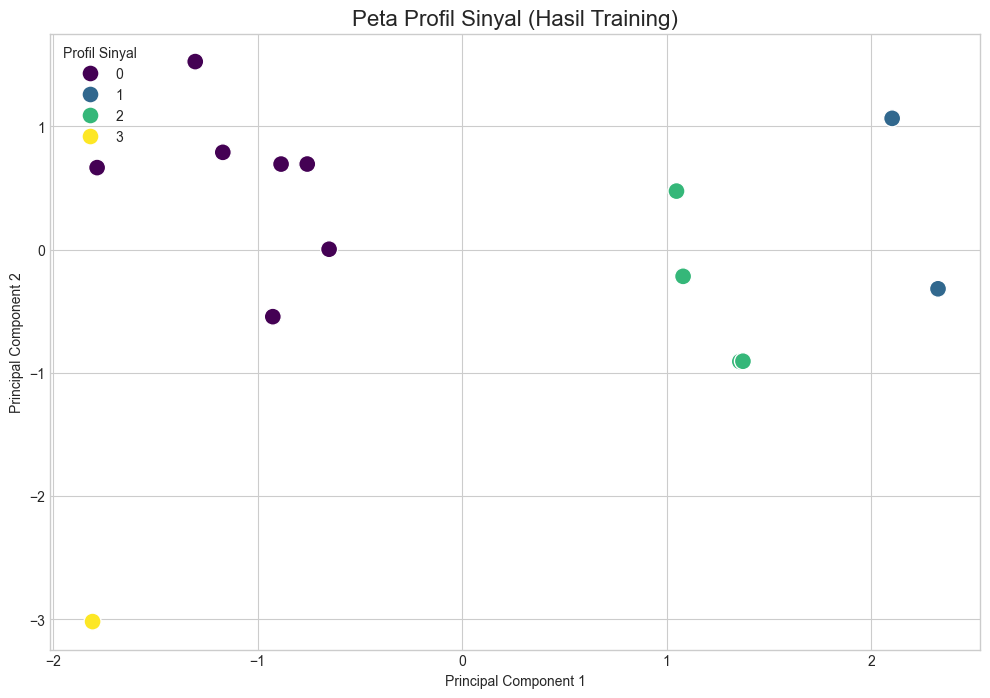

In [4]:
# Buat folder assets jika belum ada
ASSETS_PATH = '../assets/'
os.makedirs(ASSETS_PATH, exist_ok=True)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=150, legend='full')
plt.title('Peta Profil Sinyal (Hasil Training)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Profil Sinyal')
plt.grid(True)

# Simpan gambar sebelum ditampilkan
output_fig_path = os.path.join(ASSETS_PATH, 'pca_signal_profiles.png')
plt.savefig(output_fig_path)
print(f"Gambar PCA disimpan di: {output_fig_path}")

plt.show()

### Menyimpan Model Terlatih

Ini adalah langkah kritis. Kita menyimpan objek `scaler`, `pca`, dan `kmeans` yang sudah 'belajar' dari data training. Dengan menyimpan model ini, kita bisa memuatnya kembali di notebook lain atau dalam aplikasi produksi untuk menganalisis data baru tanpa perlu melakukan training ulang.

In [5]:
MODELS_PATH = '../models/'
if not os.path.exists(MODELS_PATH):
    os.makedirs(MODELS_PATH)

joblib.dump(scaler, os.path.join(MODELS_PATH, 'scaler.joblib'))
joblib.dump(pca, os.path.join(MODELS_PATH, 'pca.joblib'))
joblib.dump(kmeans, os.path.join(MODELS_PATH, 'kmeans.joblib'))

print(f"Model berhasil disimpan di direktori: {MODELS_PATH}")

Model berhasil disimpan di direktori: ../models/
